In [1]:
import re
import pandas as pd
import numpy as np
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import RegexpTokenizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


HELPER FUNCTIONS

In [2]:
stop_words_set = set(stopwords.words('english'))
stop_words_set.update(['@', 'RT'])

def to_lowercase(text):
    return text.lower()

def strip_urls(text):
    url_regex = re.compile(r'https?://\S+|www\.\S+')
    return url_regex.sub(r'', text)

def strip_emojis(input_string):
    emoji_regex = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+",
        flags=re.UNICODE
    )
    return emoji_regex.sub(r' ', input_string)

def clean_text(raw_text):
    raw_text = re.sub(r'@[A-Za-z0-9_]+', ' ', raw_text)
    raw_text = re.sub(r'#[A-Za-z0-9_]+', '', raw_text)
    raw_text = re.sub(r'[^0-9A-Za-z ]', '', raw_text)
    raw_text = strip_emojis(raw_text)
    raw_text = raw_text.replace('  ', ' ')
    return raw_text.strip()

def filter_stopwords(token_list):
    return [token for token in token_list if token not in stop_words_set]

def lemmatize_tokens(token_list):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(token, pos='v') for token in token_list]

def stem_tokens(token_list):
    stemmer = PorterStemmer()
    return [stemmer.stem(token) for token in token_list]

Text Cleaning Pipeline

In [3]:
def text_cleaning_pipeline(raw_text, strategy='lemmatize'):
    raw_text = to_lowercase(raw_text)
    raw_text = strip_urls(raw_text)
    raw_text = strip_emojis(raw_text)
    raw_text = clean_text(raw_text)
    token_list = raw_text.split()
    token_list = filter_stopwords(token_list)
    if strategy == 'lemmatize':
        token_list = lemmatize_tokens(token_list)
    elif strategy == 'stem':
        token_list = stem_tokens(token_list)
    return ' '.join(token_list)

# quick test
sample_text = "Hello @gabe_flomo 👋🏾, I still want us to hit that new sushi spot??? LMK when you're free! #sushiBros"
print(text_cleaning_pipeline(sample_text))

hello still want us hit new sushi spot lmk youre free


#Text Classification using Machine Learning Models
📝 Instructions: Trump Tweet Sentiment Classification
Load the Dataset
Load the dataset named "trump_tweet_sentiment_analysis.csv" using pandas. Ensure the dataset contains at least two columns: "text" and "label".

Text Cleaning and Tokenization
Apply a text preprocessing pipeline to the "text" column. This should include:

Lowercasing the text
Removing URLs, mentions, punctuation, and special characters
Removing stopwords
Tokenization (optional: stemming or lemmatization)
"Complete the above function"
Train-Test Split
Split the cleaned and tokenized dataset into training and testing sets using train_test_split from sklearn.model_selection.

TF-IDF Vectorization
Import and use the TfidfVectorizer from sklearn.feature_extraction.text to transform the training and testing texts into numerical feature vectors.

Model Training and Evaluation
Import Logistic Regression (or any machine learning model of your choice) from sklearn.linear_model. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.

Print the classification report using classification_report from sklearn.metrics.

In [4]:
df = pd.read_csv("/content/drive/MyDrive/AI and Machine Learning/Workshop_8/trum_tweet_sentiment_analysis.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(1850123, 2)
['text', 'Sentiment']


,text,Sentiment
0,RT @JohnLeguizamo: #trump not draining swamp b...,0
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,0
2,Trump protests: LGBTQ rally in New York https:...,1
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",0
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,0


Step 2 - Clean the text

In [6]:
df['cleaned_text'] = df['text'].dropna().apply(
    lambda raw_text: text_cleaning_pipeline(str(raw_text), strategy='lemmatize')
)

df = df[df['cleaned_text'].str.strip() != '']
df = df.dropna(subset=['cleaned_text'])

print(f"Dataset size after cleaning: {df.shape}")
df[['text', 'cleaned_text']].head()

Dataset size after cleaning: (1849904, 3)


,text,cleaned_text
0,RT @JohnLeguizamo: #trump not draining swamp b...,rt drain swamp taxpayer dollars trip advertise...
1,ICYMI: Hackers Rig FM Radio Stations To Play A...,icymi hackers rig fm radio station play antitr...
2,Trump protests: LGBTQ rally in New York https:...,trump protest lgbtq rally new york via
3,"""Hi I'm Piers Morgan. David Beckham is awful b...",hi im piers morgan david beckham awful donald ...
4,RT @GlennFranco68: Tech Firm Suing BuzzFeed fo...,rt tech firm sue buzzfeed publish unverified t...


Step 3 - Train/test split

In [7]:
from sklearn.model_selection import train_test_split

feature_series = df['cleaned_text']
label_series = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    feature_series, label_series, test_size=0.2, random_state=42, stratify=label_series
)

print(f'train samples: {len(X_train)}, test samples: {len(X_test)}')

train samples: 1479923, test samples: 369981


Step 4 - TF-IDF vectorization

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f'train matrix: {X_train_tfidf.shape}, test matrix: {X_test_tfidf.shape}')

train matrix: (1479923, 10000), test matrix: (369981, 10000)


Step 5 - Train and evaluate

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

logistic_classifier = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
logistic_classifier.fit(X_train_tfidf, y_train)

y_pred_labels = logistic_classifier.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_labels))
print(f'accuracy: {accuracy_score(y_test, y_pred_labels):.4f}')

              precision    recall  f1-score   support

           0       0.93      0.96      0.94    248808
           1       0.90      0.86      0.88    121173

    accuracy                           0.93    369981
   macro avg       0.92      0.91      0.91    369981
weighted avg       0.92      0.93      0.92    369981

accuracy: 0.9251


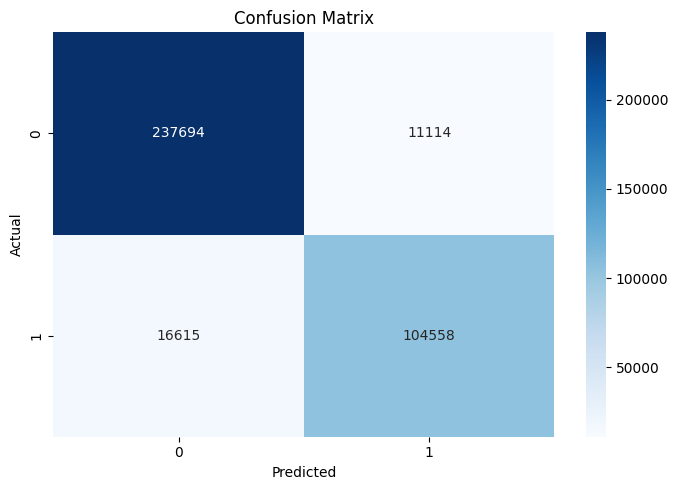

In [10]:
confusion_mat = confusion_matrix(y_test, y_pred_labels, labels=logistic_classifier.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=logistic_classifier.classes_, yticklabels=logistic_classifier.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()